# Breast Cancer Classification with Dimensionality Reduction

## Objective
In this project, we aim to **classify breast cancer tumors as either malignant or benign** using a machine learning model. We'll start by training a model with all available features, then apply dimensionality reduction to simplify the feature space and retrain the model. The goal is to demonstrate that we can achieve similar accuracy even with fewer features.

## Step 1: Loading the Dataset
First, we need to load the `Breast Cancer` dataset, which is available directly in the `Scikit-learn` library. This dataset contains 30 features related to cancer cells, which will help us classify the tumor.

- We are using the load_breast_cancer function from Scikit-learn to access the dataset.
- The dataset is converted to a Pandas DataFrame for easier analysis.
- We added the target column to indicate whether the tumor is benign (1) or malignant (0).

In [1]:
# Import libraries and load the dataset
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load the data and convert it into a DataFrame
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target


df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Step 2: Exploratory Data Analysis (EDA)

Before training our model, we need to understand the dataset. We will explore the data by checking for patterns and visualizing key features.

### 2.1 Visualization of Target Classes

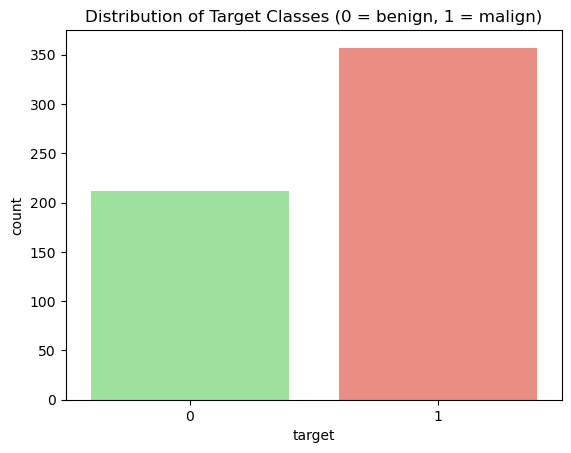

In [2]:
# Visualizing the distribution of target classes
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='target', data=df, palette=['lightgreen', 'salmon'])
plt.title("Distribution of Target Classes (0 = benign, 1 = malign)")

plt.show()


- This plot shows how the target classes are distributed. In our case, there are more benign tumors than malignant ones.
- Understanding the distribution helps us ensure that the dataset is balanced or if any adjustments are needed.


### 2.2 Correlation Heatmap
A correlation heatmap helps us understand how features are related to each other. High correlation between features can indicate redundant information, and it's useful to know this before building a model.

- Positive correlation means that as one feature increases, the other tends to increase as well, while negative correlation means that as one increases, the other decreases.
- This helps identify features that are strongly correlated, which may provide similar information to the model. For example, features with correlation close to 1 or -1 are strongly related.

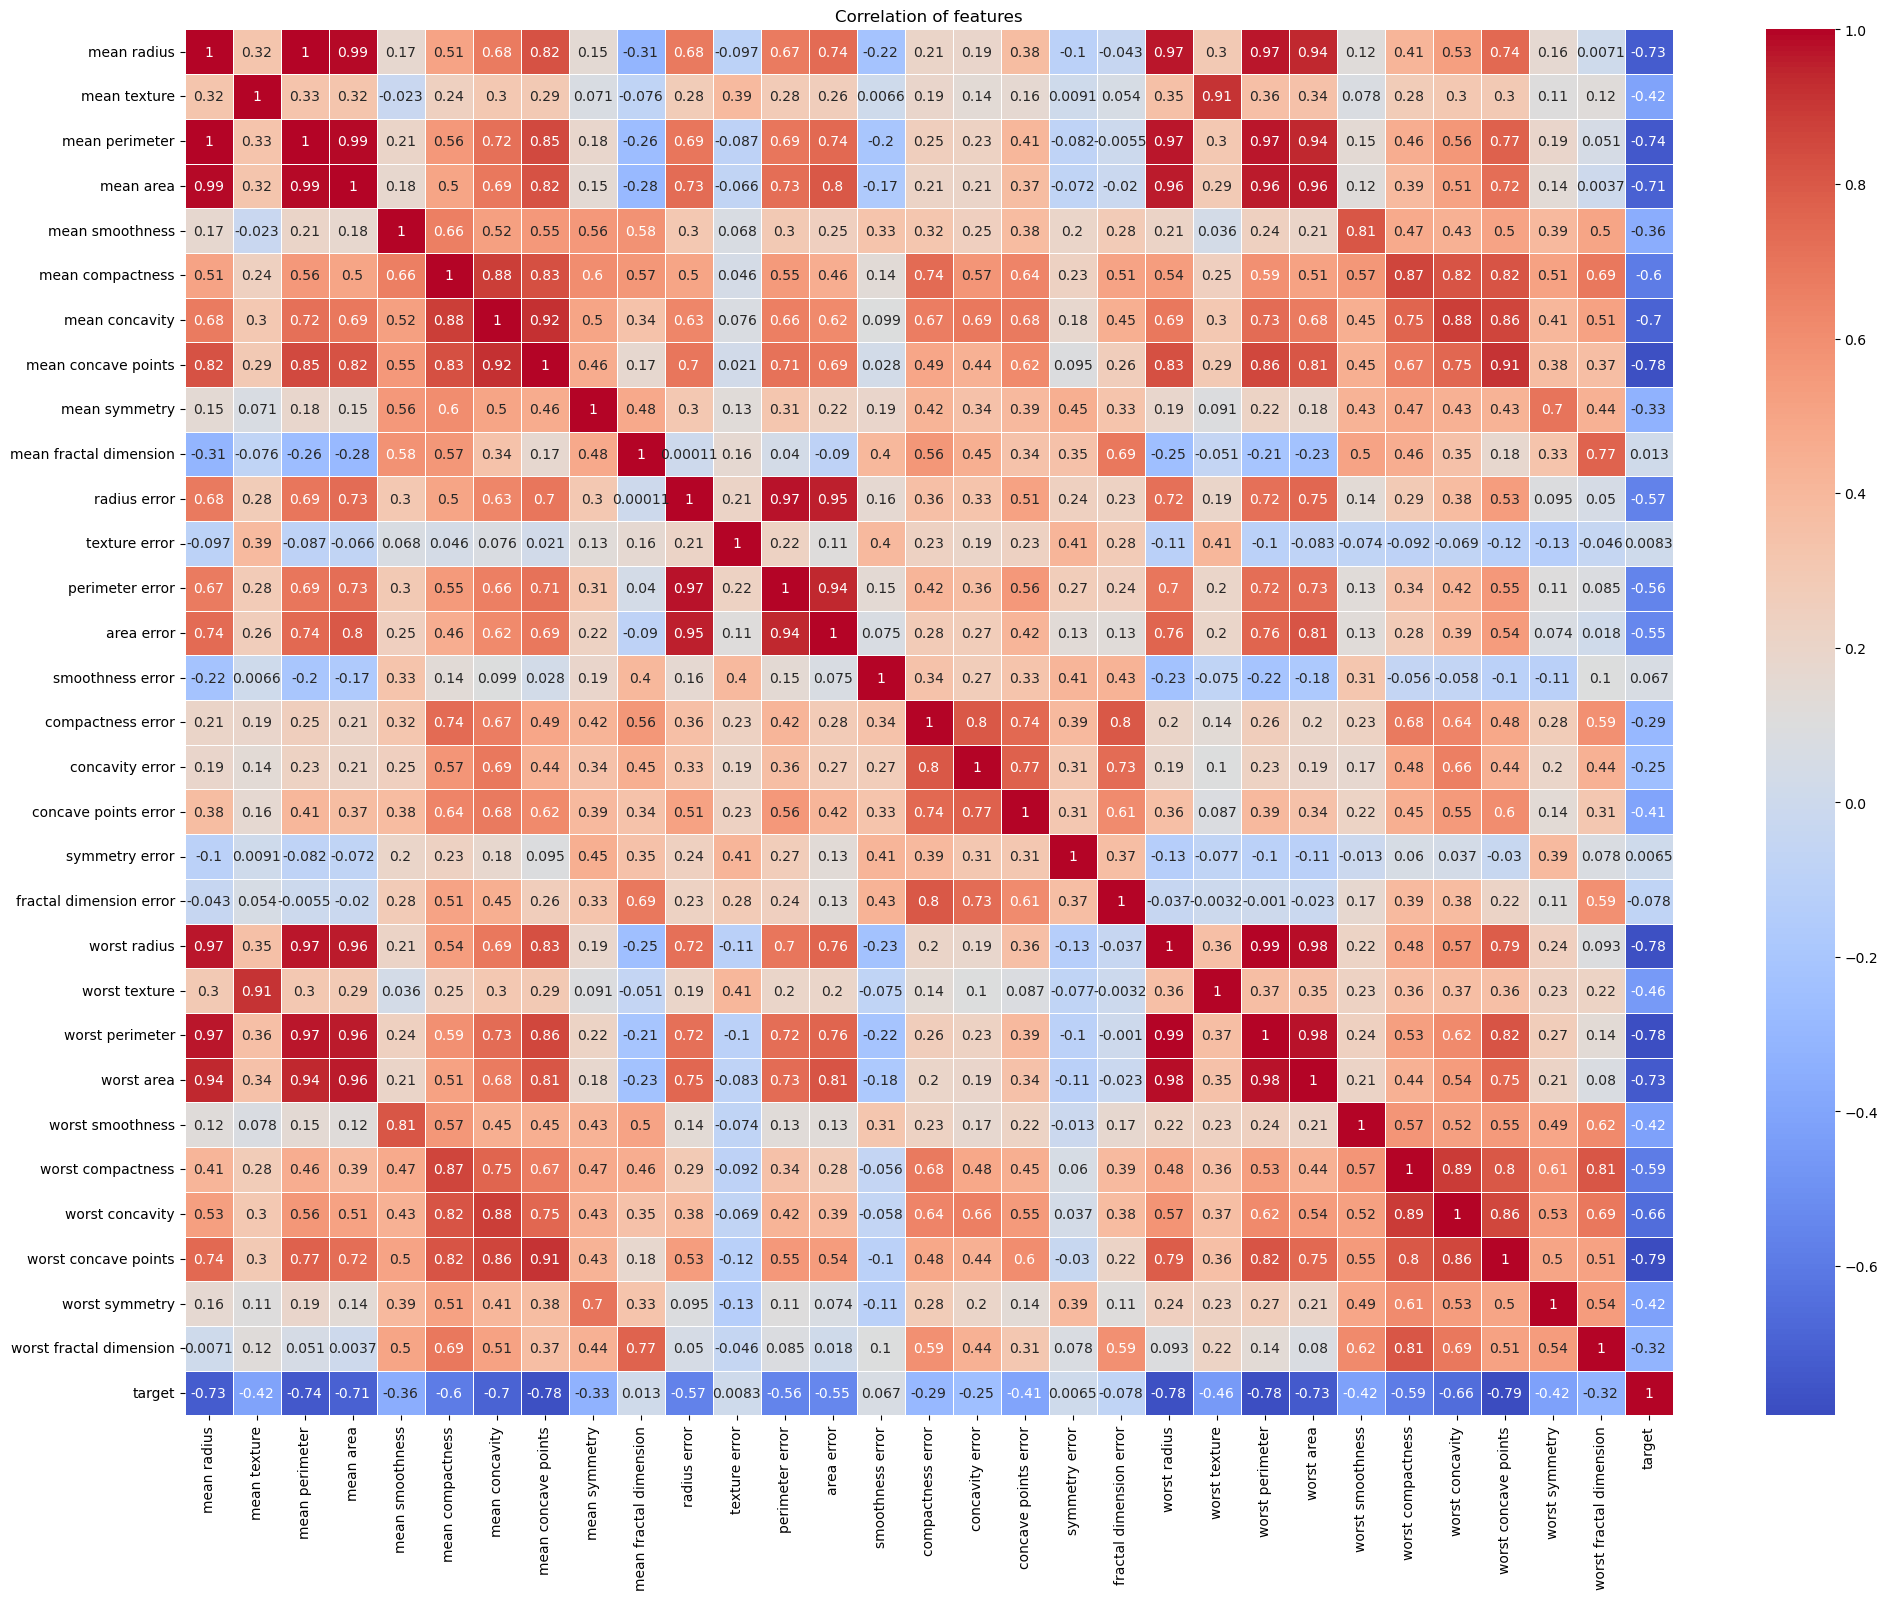

In [3]:
# Correlation heatmap of features
plt.figure(figsize=(24, 18))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.4)
plt.title("Correlation of features")
plt.show()

Here are some key insights from the correlation heatmap:

- High correlation within `radius`, `perimeter`, and `area`: **Features like mean radius, mean perimeter, and mean area have very high correlations** (close to 1.0). This indicates strong linear relationships between these geometric measurements of the tumor

- Concavity and compactness are strongly correlated: **Both mean compactness and mean concavity show high correlations with each other** and with mean concave points. These features are related to the shape irregularities of the tumor.

- **Worst measurements closely align with their mean counterparts**: The worst radius, worst perimeter, and worst area have very high correlations with mean radius, mean perimeter, and mean area, indicating that the worst-case measurements follow similar trends as the average values.

- Target correlation: **The target variable (indicating malignant or benign tumors) shows a strong negative correlation with mean radius, mean perimeter, and mean concave points**. This implies larger tumors and more irregular shapes are associated with malignant cases.

- **Texture features are less correlated**: Mean texture and worst texture have relatively lower correlations with other features, suggesting texture might provide independent information about the tumor structure compared to size-related metrics.

These insights suggest that size and shape metrics are highly interrelated, while texture offers a more unique perspective on tumor characteristics

### 2.3 Box Plot of Important Features
A box plot helps us visualize the distribution of individual features, including the median, quartiles, and potential outliers. We can compare these distributions for each class to see if any feature clearly separates the two categories.

- The box plot allows us to compare the distribution of the mean radius feature between benign and malignant tumors.
- The median line in the box represents the central tendency, while the whiskers show the range of the data.
- Box plots highlight the presence of outliers (points outside the whiskers) and help visually identify whether the feature values differ significantly between the two classes.

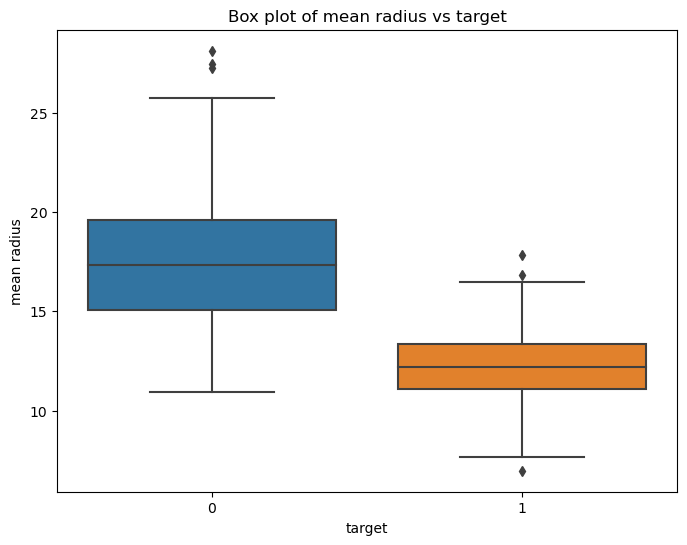

In [4]:
# Box plot for one important feature (mean radius)
plt.figure(figsize=(8, 6))
sns.boxplot(x='target', y='mean radius', data=df)
plt.title("Box plot of mean radius vs target")
plt.show()

## Step 3: Preprocessing the Data
Now, we prepare the data for training. First, we split the dataset into training and testing sets. Then, we will scale the features to ensure that they are all on the same scale.

- **Train-test split**: We split the data into two sets: one for training the model and one for testing its accuracy.
- **Scaling**: We use `StandardScaler` to ensure that all features have the same scale, which improves model performance, especially for algorithms that are sensitive to the range of input values.

In [6]:
# Splitting the dataset into training and testing sets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)


## Step 4: Training the Model
We'll use a Random Forest Classifier, a powerful machine learning model, to predict whether a tumor is malignant or benign. We first train it using all 30 features

A **Random Forest is an ensemble learning method** that combines multiple decision trees to improve prediction accuracy and control overfitting. 

**Each decision tree is trained on a random subset of the data and features**, which introduces diversity among the trees. During training, each tree makes a prediction, and the Random Forest aggregates these predictions, typically by voting (for classification) or averaging (for regression), to produce a final result.

The key advantage of Random Forest is its **ability to handle large datasets with many features and reduce the risk of overfitting compared to a single decision tree**.

![Example Image](https://tikz.net/janosh/random-forest.png)


- Random Forest: This is an ensemble learning method that builds multiple decision trees and averages their results to improve accuracy.
- We check the accuracy and classification report to evaluate how well the model performs on unseen test data.

In [8]:
# Training the Random Forest model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Accuracy", accuracy_score(y_test, y_pred))
print("Classification report", classification_report(y_test, y_pred))


Accuracy 0.9707602339181286
Classification report               precision    recall  f1-score   support

           0       0.98      0.94      0.96        63
           1       0.96      0.99      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



## Step 5: Dimensionality Reduction using PCA
Now, we’ll reduce the number of features using Principal Component Analysis (PCA). PCA transforms the original features into a smaller set while retaining as much variance (information) as possible.

Principal Component Analysis (PCA) is a **technique used for dimensionality reduction while preserving as much variance (information) in the data as possible**. 

It transforms the original data into a new set of orthogonal (uncorrelated) components called principal components. These **components are ordered by the amount of variance they capture from the data**, with the first few components often retaining the most significant patterns and information.

The primary advantage of PCA is its ability to **simplify complex datasets by reducing the number of dimensions**, making the data easier to visualize and analyze. This reduction helps in removing noise and redundancy, leading to improved performance of machine learning algorithms and more efficient storage and processing of data.

- PCA: It reduces the dataset's dimensionality by creating new features that are combinations of the original ones, while still preserving most of the important information.
- We have chosen to reduce the number of features to 5 to simplify the model.

In [18]:
# Apply PCA for dimensionality reduction
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.fit_transform(X_test_scaled)

## Step 6: Retraining the Model with Reduced Features
After reducing the dimensionality, we retrain the Random Forest model using only the top 5 principal components.

- We retrain the Random Forest model using the reduced feature set.
- Even though we reduced the features, the accuracy should remain similar, which demonstrates that we can simplify the model without losing much predictive power.

In [19]:
# Train Random Forest with reduced features
model_pca = RandomForestClassifier(random_state=42)
model_pca.fit(X_train_pca, y_train)

y_pred_pca = model_pca.predict(X_test_pca)
print("Classification report", classification_report(y_test, y_pred_pca))

Classification report               precision    recall  f1-score   support

           0       0.94      0.94      0.94        63
           1       0.96      0.96      0.96       108

    accuracy                           0.95       171
   macro avg       0.95      0.95      0.95       171
weighted avg       0.95      0.95      0.95       171



## Step 7: Visualizing PCA Variance

Finally, we check how much variance is captured by each principal component. This helps us understand how effective our dimensionality reduction is.

- **Explained Variance**: This plot shows how much information is captured by each component. A steep curve means fewer components can explain a large portion of the data variance.

In [ ]:
import numpy as np

# Visualizing explained variance by PCA components

## Conclusion
In this project, we:

- Trained a machine learning model on the Breast Cancer dataset using all features.
- Applied PCA to reduce the number of features from 30 to 10.
- Reevaluated the model with the reduced features, showing that the accuracy remained high, demonstrating the effectiveness of dimensionality reduction.
- By using PCA, we simplified the model while maintaining strong performance, which is often important in real-world scenarios where we need efficient models that generalize well with fewer features.